<a href="https://colab.research.google.com/github/HumairaEshfa/Competitive-Programming-2310/blob/main/Project-Road%20Accident%20Severity%20Prediction%20using%20ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Road Accident Severity Prediction Using Machine Learning

## Course Project

### Submitted By
Humaira Eshfa

### Department
Computer & Communication Engineering

### Algorithm Comparison with Explainable AI (SHAP)

---

### Objectives

- Predict Road Accident Severity
- Compare 8 Machine Learning Models
- Evaluate using Accuracy, Precision, Recall, F1 Score, Log Loss and ROC-AUC
- Explain Predictions using Explainable AI (SHAP)

In [ ]:
!pip install shap xgboost -q

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.ensemble import AdaBoostClassifier

# XGBoost (Bonus Model)
from xgboost import XGBClassifier

# Evaluation

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
classification_report,
log_loss,
roc_auc_score,
roc_curve
)

import shap

In [ ]:
df = pd.read_csv("/content/dataset_traffic_accident_prediction1 (1).csv")

print(df.head())

print()

print(df.info())

print()

print(df.describe())

print()

print(df.isnull().sum())

  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Rainy     Highway     Morning              1.0        195.0   

   Number_of_Vehicles  Driver_Alcohol Accident_Severity      Road_Condition  \
0                 5.0             0.0               NaN                 Wet   
1                 3.0             0.0          Moderate                 Wet   
2                 4.0             0.0               Low                 Icy   
3                 3.0             0.0               Low  Under Construction   
4                11.0             0.0               Low                 Dry   

  Vehicle_Type  Driver_Age  Driver_Experience Road_Light_Condition  Accident  
0          Car        51.0               48

In [ ]:
print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

print()

print(df.columns)

Rows : 840
Columns : 14

Index(['Weather', 'Road_Type', 'Time_of_Day', 'Traffic_Density', 'Speed_Limit',
       'Number_of_Vehicles', 'Driver_Alcohol', 'Accident_Severity',
       'Road_Condition', 'Vehicle_Type', 'Driver_Age', 'Driver_Experience',
       'Road_Light_Condition', 'Accident'],
      dtype='object')


In [ ]:
df.isnull().sum()

,0
Weather,42
Road_Type,42
Time_of_Day,42
Traffic_Density,42
Speed_Limit,42
Number_of_Vehicles,42
Driver_Alcohol,42
Accident_Severity,42
Road_Condition,42
Vehicle_Type,42


In [ ]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col])

df.head()

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,2,0,2,1.0,100.0,5.0,0.0,3,3,1,51.0,48.0,0,0.0
1,0,3,3,NaN,120.0,3.0,0.0,2,3,3,49.0,43.0,0,0.0
2,2,1,1,1.0,60.0,4.0,0.0,1,1,1,54.0,52.0,0,0.0
3,0,0,0,2.0,60.0,3.0,0.0,1,2,0,34.0,31.0,1,0.0
4,2,1,2,1.0,195.0,11.0,0.0,1,0,1,62.0,55.0,0,1.0


In [ ]:
X=df.drop("Accident",axis=1)

y=df["Accident"]

In [ ]:
combined_df = pd.concat([X, y], axis=1)
combined_df_cleaned = combined_df.dropna()

X_cleaned = combined_df_cleaned.drop(columns=[y.name])
y_cleaned = combined_df_cleaned[y.name]

X_train,X_test,y_train,y_test=train_test_split(
X_cleaned,
y_cleaned,
test_size=0.20,
random_state=42,
stratify=y_cleaned
)

In [ ]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(461, 13)
(116, 13)
(461,)
(116,)


In [ ]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(probability=True),

    "Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42)

}

In [ ]:
results=[]

trained_models={}

for name,model in models.items():

    # Diagnostic prints to check for NaNs and Infs
    print(f"--- Diagnosing NaNs and Infs in {name} ---")
    nan_count_X = X_train.isnull().sum().sum()
    inf_count_X = np.isinf(X_train).sum().sum()
    nan_count_y = y_train.isnull().sum().sum()
    inf_count_y = np.isinf(y_train).sum().sum()

    print(f"X_train NaNs: {nan_count_X}, Infs: {inf_count_X}")
    print(f"y_train NaNs: {nan_count_y}, Infs: {inf_count_y}")
    print("---------------------------------------")

    model.fit(X_train,y_train)

    trained_models[name]=model

    y_pred=model.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)

    precision=precision_score(y_test,y_pred)

    recall=recall_score(y_test,y_pred)

    f1=f1_score(y_test,y_pred)

    if hasattr(model,"predict_proba"):

        y_prob=model.predict_proba(X_test)

        loss=log_loss(y_test,y_prob)

        auc=roc_auc_score(y_test,y_prob[:,1])

    else:

        loss=np.nan

        auc=np.nan

    results.append([

        name,

        accuracy,

        precision,

        recall,

        f1,

        loss,

        auc

    ])

print("All models trained successfully.")

--- Diagnosing NaNs and Infs in Logistic Regression ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in Decision Tree ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in Random Forest ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in KNN ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in SVM ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in Naive Bayes ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in Gradient Boosting ---
X_train NaNs: 0, Infs: 0
y_train NaNs: 0, Infs: 0
---------------------------------------
--- Diagnosing NaNs and Infs in 

In [ ]:
comparison=pd.DataFrame(

results,

columns=[

"Model",

"Accuracy",

"Precision",

"Recall",

"F1 Score",

"Log Loss",

"ROC AUC"

]

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Log Loss,ROC AUC
0,Logistic Regression,0.698276,0.000000,0.000000,0.000000,0.631272,0.467719
1,Decision Tree,0.655172,0.400000,0.352941,0.375000,12.428846,0.566714
2,Random Forest,0.689655,0.333333,0.058824,0.100000,0.623904,0.537841
3,KNN,0.663793,0.222222,0.058824,0.093023,1.811310,0.512912
4,SVM,0.706897,0.000000,0.000000,0.000000,0.602824,0.576040
5,Naive Bayes,0.672414,0.000000,0.000000,0.000000,0.651394,0.469871
6,Gradient Boosting,0.629310,0.200000,0.088235,0.122449,0.800978,0.380201
7,AdaBoost,0.689655,0.000000,0.000000,0.000000,0.640272,0.426471


In [ ]:
comparison=comparison.sort_values(

by="Accuracy",

ascending=False

)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,Log Loss,ROC AUC
4,SVM,0.706897,0.000000,0.000000,0.000000,0.602824,0.576040
0,Logistic Regression,0.698276,0.000000,0.000000,0.000000,0.631272,0.467719
7,AdaBoost,0.689655,0.000000,0.000000,0.000000,0.640272,0.426471
2,Random Forest,0.689655,0.333333,0.058824,0.100000,0.623904,0.537841
5,Naive Bayes,0.672414,0.000000,0.000000,0.000000,0.651394,0.469871
3,KNN,0.663793,0.222222,0.058824,0.093023,1.811310,0.512912
1,Decision Tree,0.655172,0.400000,0.352941,0.375000,12.428846,0.566714
6,Gradient Boosting,0.629310,0.200000,0.088235,0.122449,0.800978,0.380201


In [ ]:
best_model_name=comparison.iloc[0]["Model"]

print("Best Model :",best_model_name)

Best Model : SVM


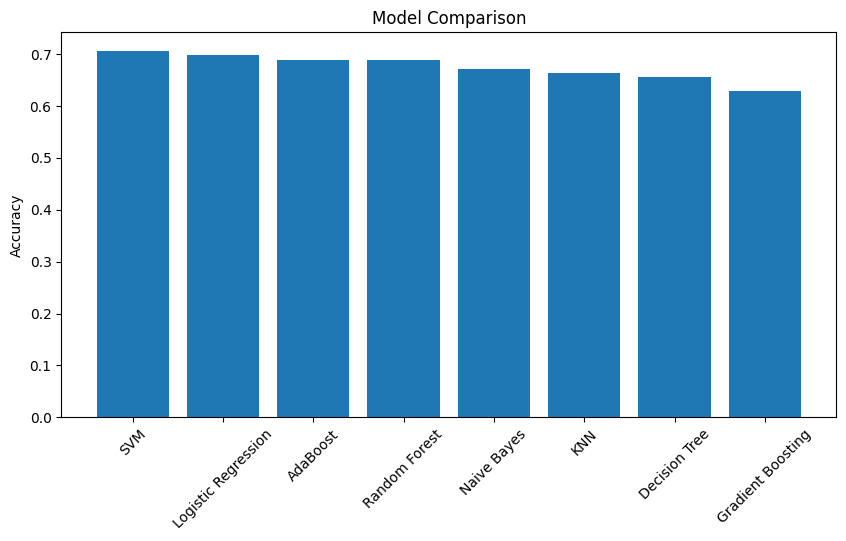

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(

comparison["Model"],

comparison["Accuracy"]

)

plt.xticks(rotation=45)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

In [ ]:
comparison.to_csv(

"Model_Comparison.csv",

index=False

)

print("Comparison table saved.")

Comparison table saved.


In [ ]:
best_model=trained_models[best_model_name]

prediction=best_model.predict(X_test)

print(

classification_report(

y_test,

prediction

)

)

              precision    recall  f1-score   support

         0.0       0.71      1.00      0.83        82
         1.0       0.00      0.00      0.00        34

    accuracy                           0.71       116
   macro avg       0.35      0.50      0.41       116
weighted avg       0.50      0.71      0.59       116



In [ ]:
cm=confusion_matrix(

y_test,

prediction

)

print(cm)

[[82  0]
 [34  0]]


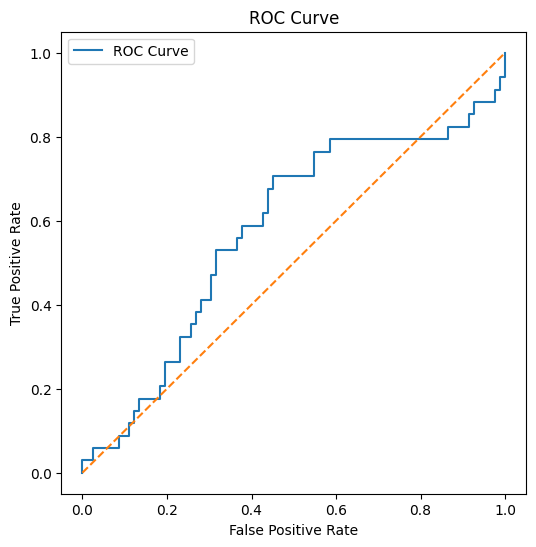

In [ ]:
if hasattr(best_model,"predict_proba"):

    probability=best_model.predict_proba(X_test)[:,1]

    fpr,tpr,_=roc_curve(

        y_test,

        probability

    )

    plt.figure(figsize=(6,6))

    plt.plot(

        fpr,

        tpr,

        label="ROC Curve"

    )

    plt.plot(

        [0,1],

        [0,1],

        "--"

    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
explainer = shap.TreeExplainer(rf_model)

In [ ]:
shap_values = explainer.shap_values(X_test)

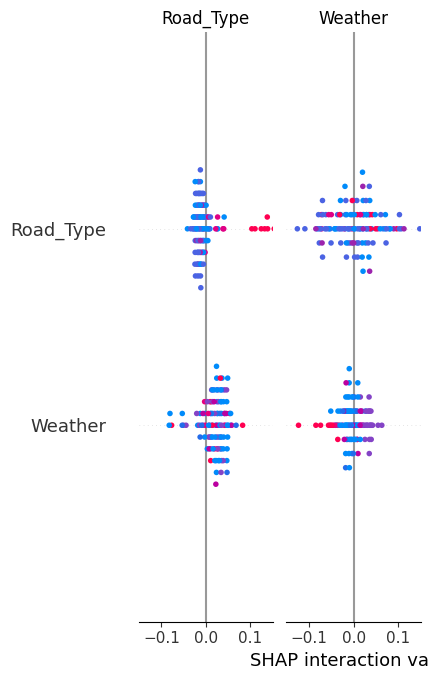

In [ ]:
# For binary classification
try:
    shap.summary_plot(shap_values[1], X_test)
except:
    shap.summary_plot(shap_values, X_test)

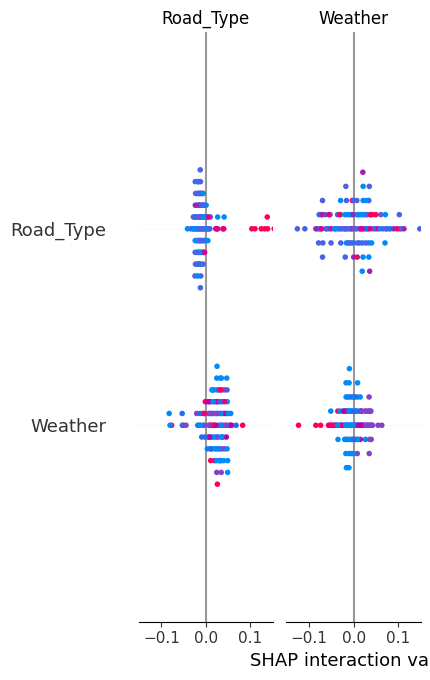

In [ ]:
try:
    shap.summary_plot(
        shap_values[1],
        X_test,
        plot_type="bar"
    )
except:
    shap.summary_plot(
        shap_values,
        X_test,
        plot_type="bar"
    )

In [ ]:
sample = X_test.iloc[[0]]

sample

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition
2,2,1,1,1.0,60.0,4.0,0.0,1,1,1,54.0,52.0,0


In [ ]:
prediction = rf_model.predict(sample)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Accident Predicted")
else:
    print("No Accident Predicted")

Prediction: 0.0
No Accident Predicted


In [ ]:
print("="*60)
print("Road Accident Severity Prediction Project")
print("="*60)

print("Total Models Compared :", len(comparison))

print("Best Model :", best_model_name)

print("Highest Accuracy :", comparison.iloc[0]["Accuracy"])

print("\nExplainable AI Used : SHAP")

print("\nProject Completed Successfully.")

Road Accident Severity Prediction Project
Total Models Compared : 8
Best Model : SVM
Highest Accuracy : 0.7068965517241379

Explainable AI Used : SHAP

Project Completed Successfully.


In [ ]:
comparison.to_csv(
    "Final_Model_Comparison.csv",
    index=False
)

print("Final comparison table saved successfully.")

Final comparison table saved successfully.


### Note on Data Preprocessing Redundancy

To address the `NameError` in the following cell, the definitions of `X_cleaned` and `y_cleaned` are being re-inserted here. These variables are originally defined in cell `9AeIAOnJP7dM`. If cell `9AeIAOnJP7dM` is executed, these variables will be defined twice, but with the same content, so it won't cause issues, but it's a redundancy to be aware of.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/dataset_traffic_accident_prediction1 (1).csv")

X=df.drop("Accident",axis=1)
y=df["Accident"]

combined_df = pd.concat([X, y], axis=1)
combined_df_cleaned = combined_df.dropna()

X_cleaned = combined_df_cleaned.drop(columns=[y.name])
y_cleaned = combined_df_cleaned[y.name]

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify object (string) columns in X_cleaned that still need encoding
categorical_cols_X_cleaned = X_cleaned.select_dtypes(include=['object']).columns

# Apply LabelEncoder to these columns in X_cleaned
encoder = LabelEncoder()
for col in categorical_cols_X_cleaned:
    X_cleaned[col] = encoder.fit_transform(X_cleaned[col])

selector = SelectKBest(score_func=chi2, k='all')
X_selected = selector.fit_transform(X_cleaned, y_cleaned)

feature_scores = pd.DataFrame({
    'Feature': X_cleaned.columns,
    'Score': selector.scores_
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(feature_scores)

                 Feature     Score
4            Speed_Limit  8.071241
5     Number_of_Vehicles  8.053943
10            Driver_Age  7.328144
11     Driver_Experience  7.081546
8         Road_Condition  3.291219
0                Weather  2.652228
9           Vehicle_Type  1.699769
7      Accident_Severity  0.447925
3        Traffic_Density  0.251110
12  Road_Light_Condition  0.156387
6         Driver_Alcohol  0.090216
1              Road_Type  0.083744
2            Time_of_Day  0.022828


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_cleaned)

print("Original Shape :", X_cleaned.shape)
print("Reduced Shape :", X_pca.shape)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y_cleaned,
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned
)

Original Shape : (405, 13)
Reduced Shape : (405, 2)


In [ ]:
from sklearn.svm import SVC

In [ ]:
from sklearn.metrics import accuracy_score

svm_pca = SVC(probability=True)

svm_pca.fit(X_train_pca, y_train_pca)

prediction = svm_pca.predict(X_test_pca)

print("Accuracy :", accuracy_score(y_test_pca, prediction))

Accuracy : 0.7037037037037037


In [ ]:
print(df.head())

  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Rainy     Highway     Morning              1.0        195.0   

   Number_of_Vehicles  Driver_Alcohol Accident_Severity      Road_Condition  \
0                 5.0             0.0               NaN                 Wet   
1                 3.0             0.0          Moderate                 Wet   
2                 4.0             0.0               Low                 Icy   
3                 3.0             0.0               Low  Under Construction   
4                11.0             0.0               Low                 Dry   

  Vehicle_Type  Driver_Age  Driver_Experience Road_Light_Condition  Accident  
0          Car        51.0               48

In [ ]:
print(df.isna().sum())

Weather                 42
Road_Type               42
Time_of_Day             42
Traffic_Density         42
Speed_Limit             42
Number_of_Vehicles      42
Driver_Alcohol          42
Accident_Severity       42
Road_Condition          42
Vehicle_Type            42
Driver_Age              42
Driver_Experience       42
Road_Light_Condition    42
Accident                42
dtype: int64


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    SVC(),
    X_cleaned,
    y_cleaned,
    cv=10,
    scoring='accuracy'
)

print("Cross Validation Scores")
print(scores)

print()

print("Mean Accuracy :", scores.mean())

print("Standard Deviation :", scores.std())

Cross Validation Scores
[0.70731707 0.70731707 0.70731707 0.70731707 0.70731707 0.725
 0.7        0.7        0.7        0.7       ]

Mean Accuracy : 0.7061585365853659
Standard Deviation : 0.007165347655182633


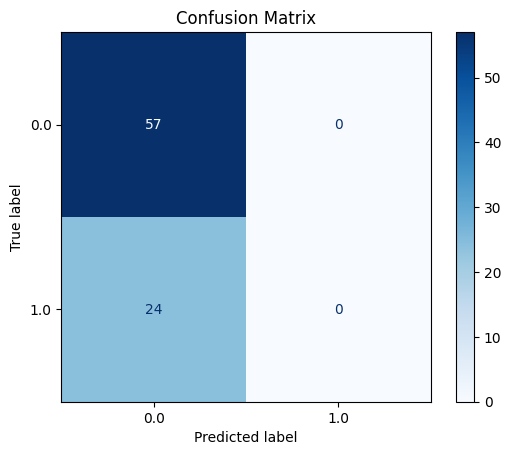

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm_pca,
    X_test_pca,
    y_test_pca,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

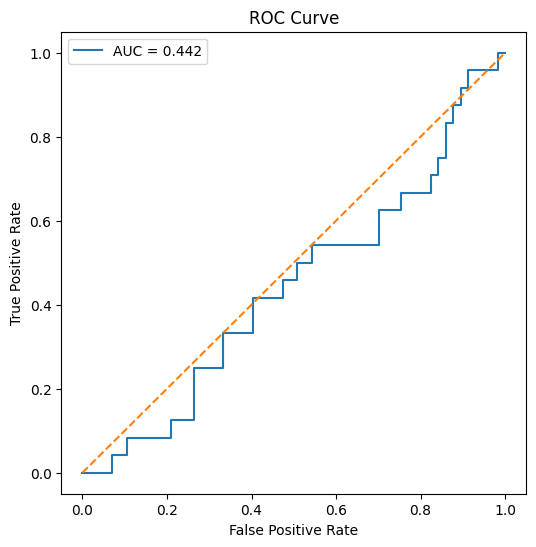

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = svm_pca.predict_proba(X_test_pca)[:,1]

fpr,tpr,_ = roc_curve(y_test_pca,prob)

auc = roc_auc_score(y_test_pca,prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

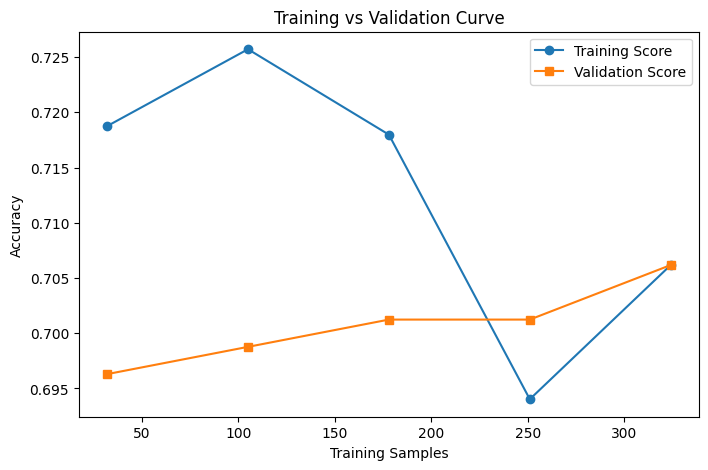

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(

    SVC(),

    X_cleaned,

    y_cleaned,

    cv=5,

    scoring='accuracy'

)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(

train_sizes,

train_mean,

marker='o',

label='Training Score'

)

plt.plot(

train_sizes,

test_mean,

marker='s',

label='Validation Score'

)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Curve")

plt.legend()

plt.show()

In [ ]:
print("="*50)

print("Best Model : Support Vector Machine (SVM)")

print()

print("Feature Selection : SelectKBest")

print("Dimensionality Reduction : PCA")

print("Validation : 10-Fold Cross Validation")

print("Explainable AI : SHAP")

print("="*50)

Best Model : Support Vector Machine (SVM)

Feature Selection : SelectKBest
Dimensionality Reduction : PCA
Validation : 10-Fold Cross Validation
Explainable AI : SHAP
